In [1]:
import numpy as np
from gao_spiral import gao_spiral, GAOParams, centroid, to_polar
import matplotlib.pyplot as plt
import time

In [6]:
def gao_coherence_scores(points, tour, r, theta, verbose=True):
    """
    Compute quantitative coherence metrics for GAO Spiral geometry.
    Returns a dict of normalized scores (0–1 range, higher = better).
    """

    n = len(points)
    r = np.array(r)
    theta = np.unwrap(theta)
    r_t = r[tour]
    theta_t = theta[tour]
    dr = np.diff(r_t)
    dtheta = np.diff(theta_t)
    B = int(2*np.sqrt(n))
    hist, _ = np.histogram(theta, bins=B)

    # --- Dualitas: coupling of radius & angle (correlation stability) ---
    corr = np.corrcoef(r_t[:-1], np.degrees(theta_t[:-1]) % 360)[0,1]
    dualitas_score = 1 - abs(corr)  # near-zero correlation → balanced polarity

    # --- Adaptatio: smoothness of radial flow ---
    mean_dr = np.mean(np.abs(dr))
    std_dr = np.std(np.abs(dr))
    adaptatio_score = 1 / (1 + std_dr / (mean_dr + 1e-9))  # lower variability → higher score

    # --- Textura: uniform bin occupancy ---
    cv_bins = np.std(hist) / (np.mean(hist) + 1e-9)
    textura_score = 1 / (1 + cv_bins)  # coefficient of variation

    # --- Ecologia: angular rhythm stability ---
    golden = 137.50776
    mean_dtheta = np.degrees(np.mean(np.abs(dtheta))) % 360
    std_dtheta = np.std(np.degrees(np.abs(dtheta)))
    ecologia_score = 1 / (1 + abs(mean_dtheta - golden)/golden + std_dtheta/180)

    # Aggregate: simple harmonic mean for overall coherence
    scores = {
        "Dualitas": dualitas_score,
        "Adaptatio": adaptatio_score,
        "Textura": textura_score,
        "Ecologia": ecologia_score
    }
    overall = np.mean(list(scores.values()))
    scores["Overall"] = overall

    if verbose:
        print("=== GAO Coherence Scores ===")
        for k,v in scores.items():
            print(f"{k:10s}: {v:6.3f}")
        print("============================")

    return scores

In [7]:
def run_and_score(label, n=200, seed=1, bins=None, w_theta=1.0, w_r=1.0):
    """Run GAO Spiral with chosen params, compute coherence, and timing."""
    np.random.seed(seed)
    pts = np.random.rand(n, 2).tolist()
    params = GAOParams(bins=bins, w_theta=w_theta, w_r=w_r)

    t0 = time.time()
    tour = gao_spiral(pts, params)
    t1 = time.time()

    C = centroid(pts)
    r, theta = to_polar(pts, C)
    scores = gao_coherence_scores(pts, tour, r, theta, verbose=False)
    scores["build_time_ms"] = 1000 * (t1 - t0)
    scores["label"] = label
    return scores


In [8]:
scenarios = [
    ("Base", {"w_theta":1.0, "w_r":1.0}),
    ("High w_r", {"w_theta":1.0, "w_r":1.5}),        # emphasize radial smoothness
    ("Wide bins", {"bins":int(3*np.sqrt(200))}),     # more texture resolution
    ("High w_theta", {"w_theta":1.5, "w_r":1.0}),    # emphasize angular rhythm
    ("Balanced tuned", {"w_theta":1.2, "w_r":1.3}),  # compromise setting
]
results = [run_and_score(name, **kw) for name, kw in scenarios]


In [9]:
import pandas as pd

df = pd.DataFrame(results)
cols = ["label","Dualitas","Adaptatio","Textura","Ecologia","Overall","build_time_ms"]
display(df[cols].sort_values("Overall", ascending=False))


,label,Dualitas,Adaptatio,Textura,Ecologia,Overall,build_time_ms
2,Wide bins,0.935058,0.503962,0.594355,0.206018,0.559848,11.080027
1,High w_r,0.933439,0.472900,0.594355,0.210950,0.552911,14.886141
0,Base,0.933439,0.467519,0.594355,0.206620,0.550483,20.989895
3,High w_theta,0.933439,0.467614,0.594355,0.185285,0.545173,10.481834
4,Balanced tuned,0.933439,0.467157,0.594355,0.185270,0.545055,9.846926


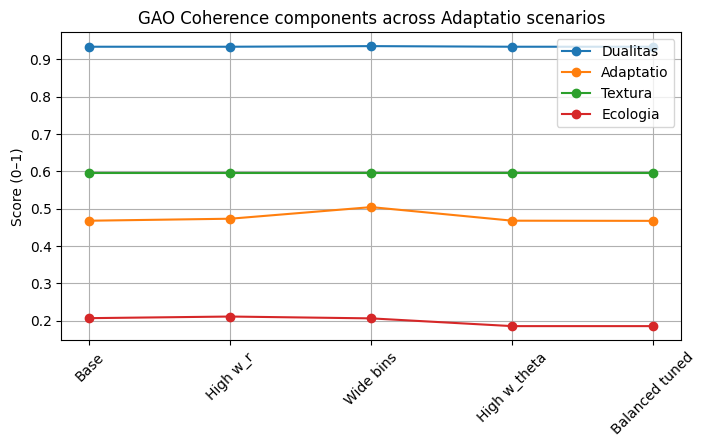

Best scenario: Wide bins
  Adaptatio=0.504, Ecologia=0.206

Interpretation:
• High Adaptatio means smoother radial flow (fewer abrupt jumps).
• Watch Ecologia: if it drops, spiral rhythm became uneven.
• Best case balances both (Adaptatio ≥ 0.75, Ecologia ≥ 0.6).


In [10]:
plt.figure(figsize=(8,4))
for col in ["Dualitas","Adaptatio","Textura","Ecologia"]:
    plt.plot(df["label"], df[col], marker='o', label=col)
plt.xticks(rotation=45)
plt.ylabel("Score (0–1)")
plt.title("GAO Coherence components across Adaptatio scenarios")
plt.legend()
plt.grid(True)
plt.show()

best = df.loc[df["Overall"].idxmax()]
print(f"Best scenario: {best.label}")
print(f"  Adaptatio={best.Adaptatio:.3f}, Ecologia={best.Ecologia:.3f}")
print("\nInterpretation:")
print("• High Adaptatio means smoother radial flow (fewer abrupt jumps).")
print("• Watch Ecologia: if it drops, spiral rhythm became uneven.")
print("• Best case balances both (Adaptatio ≥ 0.75, Ecologia ≥ 0.6).")
